# Operating Efficiency Analysis of Top 4 US Tech Giants (2020-2024)

## 1. Setup & Database Connection

In [1]:
import wrds
import pandas as pd

In [2]:
username = "lanjiaqi"
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


## 2.Data Extraction
Data period: 2019-2024 (2019 used for average balance calculation)

In [13]:
data = db.raw_sql("""
SELECT
    gvkey,                                            
    tic,                                               
    conm,                                              
    datadate,                                         
    cogs,                                         
    invt,                                     
    sale,                                           
    rect,                                           
    at                                             
FROM comp.funda                                        
WHERE
    tic IN ('AAPL', 'MSFT', 'AMZN', 'NVDA')            
    AND datadate >= '2019-01-01'                      
    AND datadate <= '2024-12-31'                       
    AND datafmt = 'STD'                                           
    AND indfmt = 'INDL'                               
    AND consol = 'C'                                 
    AND popsrc = 'D'                                 
ORDER BY tic, datadate                            
""")

data

,gvkey,tic,conm,datadate,cogs,invt,sale,rect,at
0,001690,AAPL,APPLE INC,2019-09-30,150482.0,4106.0,260174.0,45804.0,338516.0
1,001690,AAPL,APPLE INC,2020-09-30,159859.0,4061.0,274515.0,37445.0,323888.0
2,001690,AAPL,APPLE INC,2021-09-30,203481.0,6580.0,365817.0,51506.0,351002.0
3,001690,AAPL,APPLE INC,2022-09-30,214846.0,4946.0,394328.0,60932.0,352755.0
4,001690,AAPL,APPLE INC,2023-09-30,205637.0,6331.0,383285.0,60985.0,352583.0
5,001690,AAPL,APPLE INC,2024-09-30,202152.0,7286.0,391035.0,66243.0,364980.0
6,064768,AMZN,AMAZON.COM INC,2019-12-31,150386.0,19868.0,280522.0,17663.0,225248.0
7,064768,AMZN,AMAZON.COM INC,2020-12-31,217068.0,22943.0,386064.0,19981.0,321195.0
8,064768,AMZN,AMAZON.COM INC,2021-12-31,249435.0,31758.0,469822.0,26500.0,420549.0
9,064768,AMZN,AMAZON.COM INC,2022-12-31,263907.0,33457.0,513983.0,34800.0,462675.0


## 3. Calculate Efficiency Metrics
Metrics: Inventory Turnover, Receivable Turnover, Total Asset Turnover.

In [14]:
# 1. Extract year from date
data['year'] = pd.to_datetime(data['datadate']).dt.year

# 2. Sort by company and year to ensure correct rolling calculation
data = data.sort_values(['tic', 'year'])

# 3. Compute annual average balances (2-period rolling mean)
data['avg_invt'] = data.groupby('tic')['invt'].rolling(2).mean().reset_index(0, drop=True)
data['avg_rect'] = data.groupby('tic')['rect'].rolling(2).mean().reset_index(0, drop=True)
data['avg_at'] = data.groupby('tic')['at'].rolling(2).mean().reset_index(0, drop=True)

# 4. Compute three core efficiency ratios
data['inventory_turnover'] = data['sale'] / data['avg_invt']        # Inventory Turnover
data['receivable_turnover'] = data['sale'] / data['avg_rect']       # Accounts Receivable Turnover
data['total_asset_turnover'] = data['sale'] / data['avg_at']        # Total Asset Turnover

# 5. Filter final analysis period 2020–2024 (drop 2019 used only for averages)
data_final = data[data['year'] >= 2020].reset_index(drop=True)

# 6. Show key results
data_final[['tic', 'year', 'sale', 'invt', 'avg_invt', 'inventory_turnover', 'receivable_turnover', 'total_asset_turnover']]

,tic,year,sale,invt,avg_invt,inventory_turnover,receivable_turnover,total_asset_turnover
0,AAPL,2020,274515.0,4061.0,4083.5,67.225419,6.595034,0.828845
1,AAPL,2021,365817.0,6580.0,5320.5,68.756132,8.225135,1.084079
2,AAPL,2022,394328.0,4946.0,5763.0,68.424085,7.014141,1.120637
3,AAPL,2023,383285.0,6331.0,5638.5,67.976412,6.287638,1.086812
4,AAPL,2024,391035.0,7286.0,6808.5,57.433355,6.146996,1.089897
5,AMZN,2020,386064.0,22943.0,21405.5,18.035738,20.511317,1.413007
6,AMZN,2021,469822.0,31758.0,27350.5,17.177821,20.215658,1.266804
7,AMZN,2022,513983.0,33457.0,32607.5,15.762723,16.769429,1.163879
8,AMZN,2023,574785.0,32326.0,32891.5,17.475184,14.070624,1.160562
9,AMZN,2024,637959.0,33216.0,32771.0,19.467181,13.263181,1.106849


## 4. Visualization Setup

In [15]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.dpi'] = 300

## 5. Inventory Turnover Trend

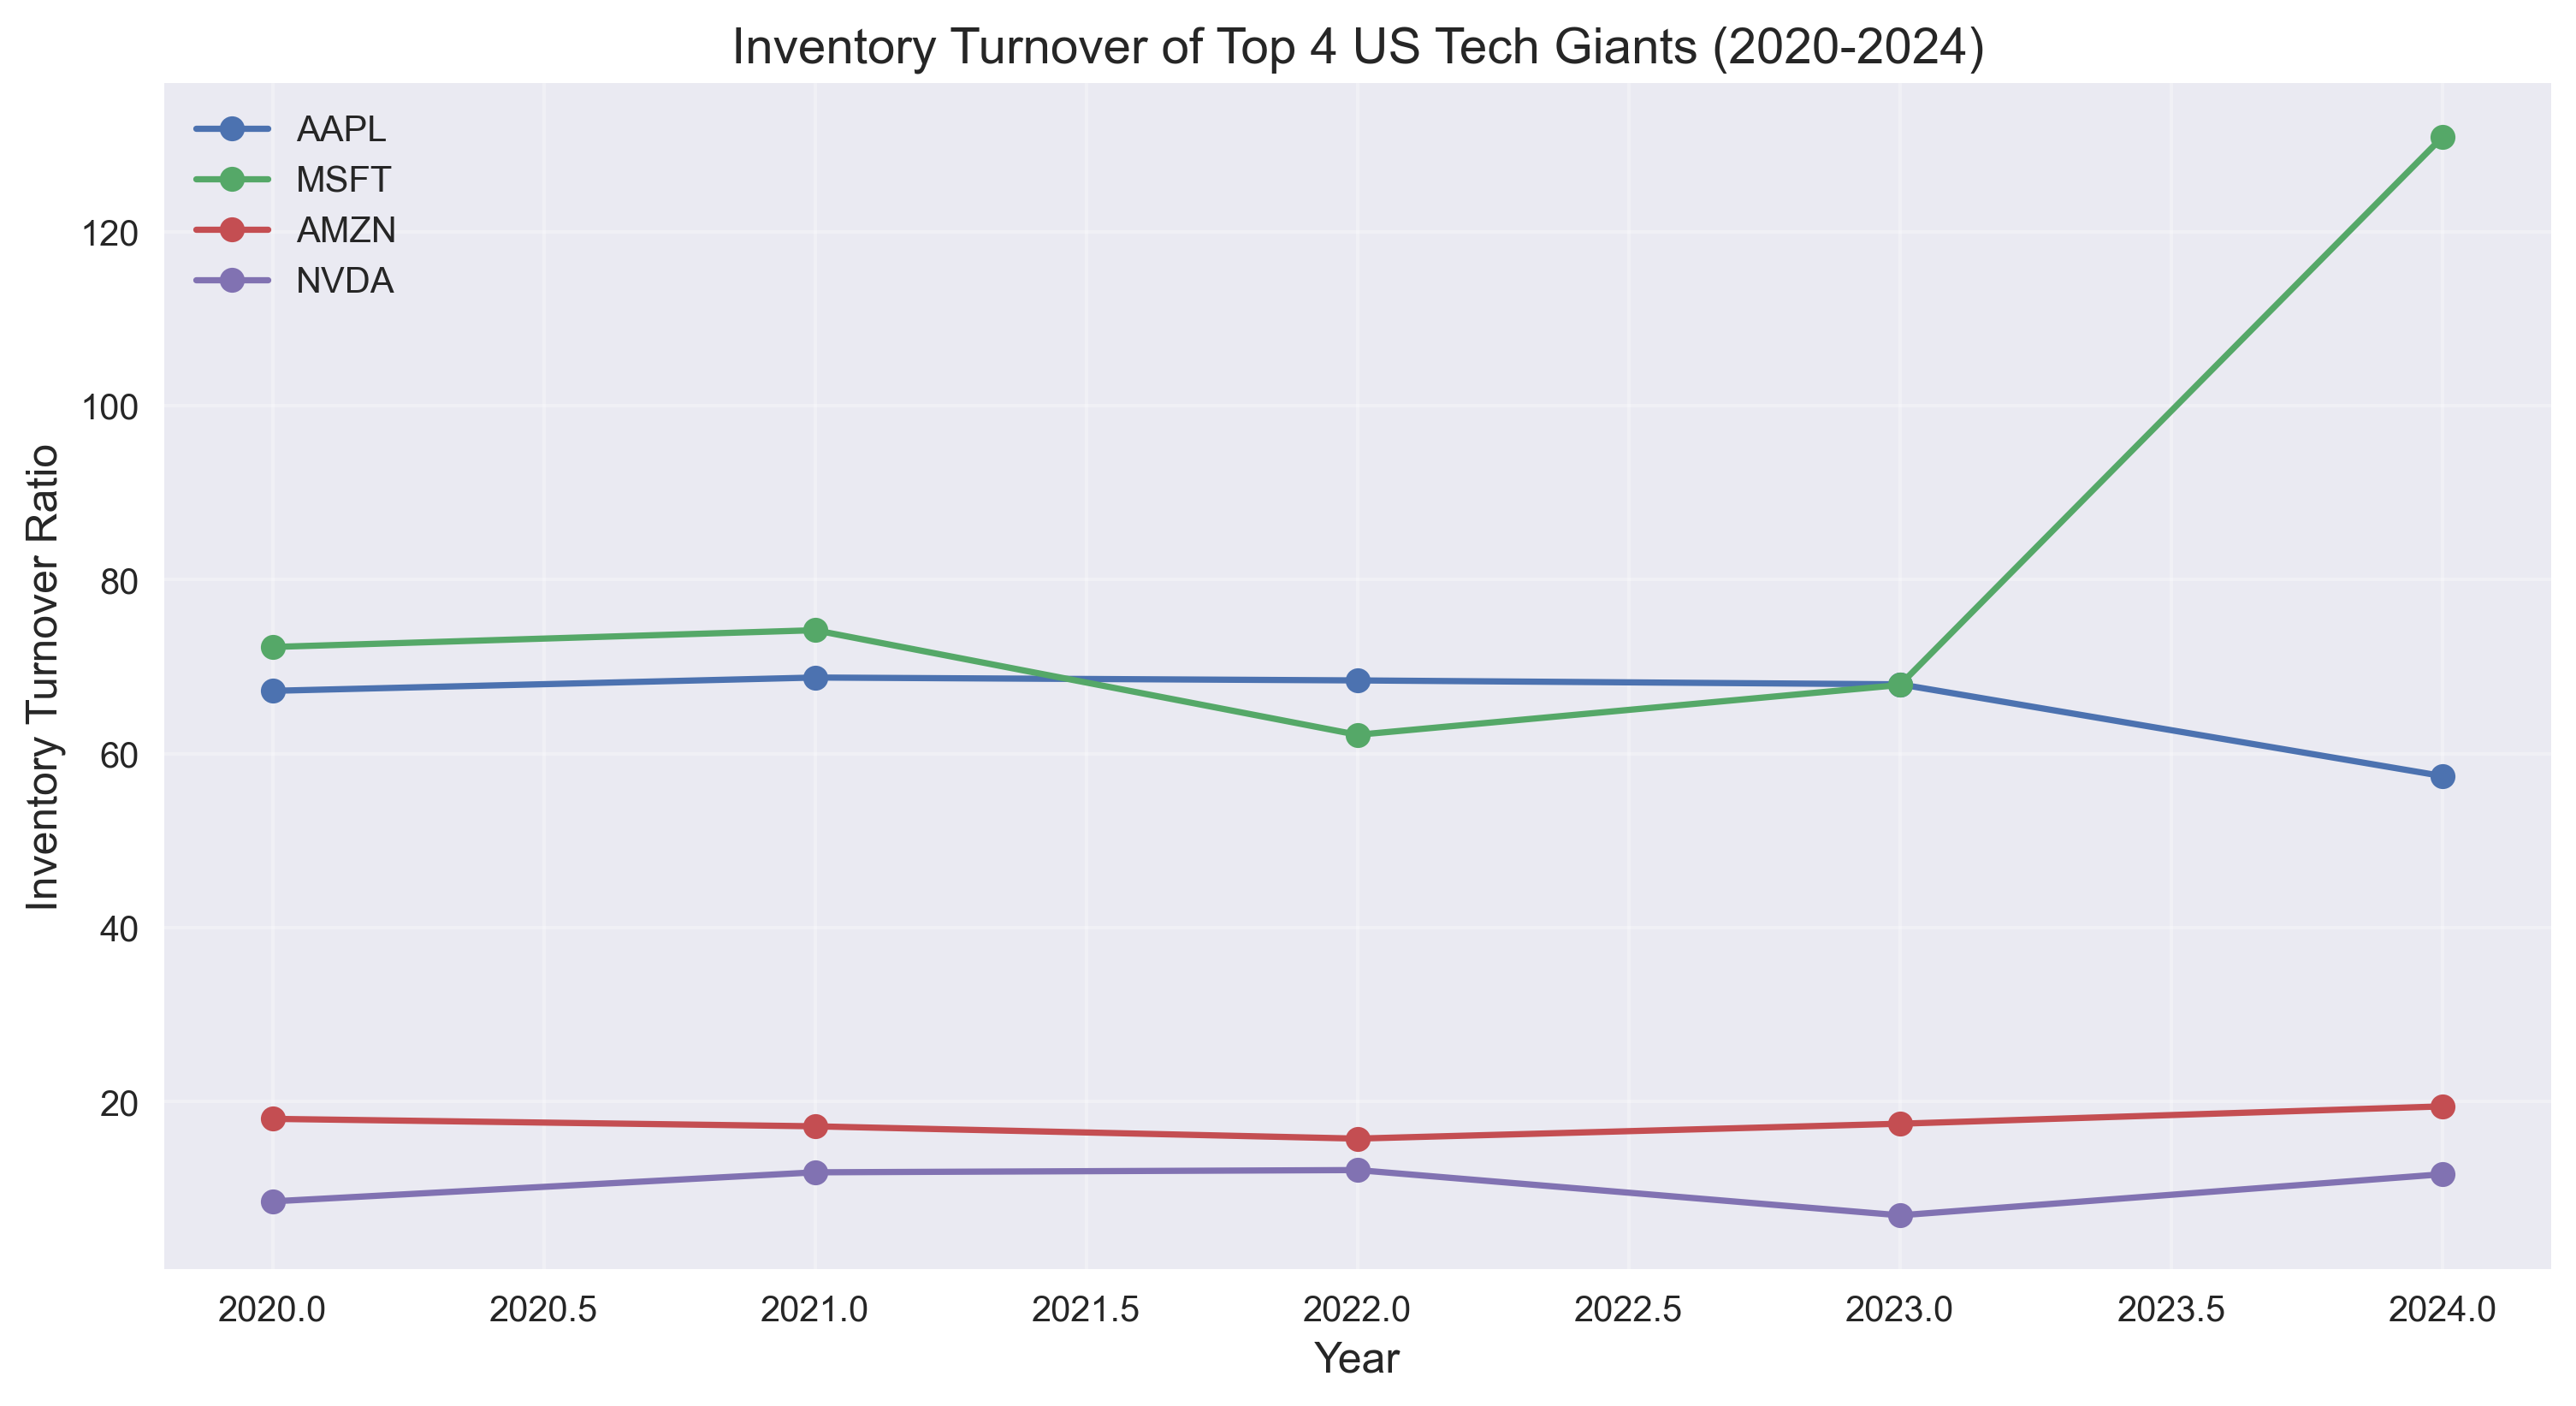

In [16]:
plt.figure(figsize=(12, 6))
for tic in ['AAPL', 'MSFT', 'AMZN', 'NVDA']:
    df = data_final[data_final['tic'] == tic]
    plt.plot(df['year'], df['inventory_turnover'], marker='o', label=tic)

plt.title('Inventory Turnover of Top 4 US Tech Giants (2020-2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Inventory Turnover Ratio', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Receivable Turnover Trend

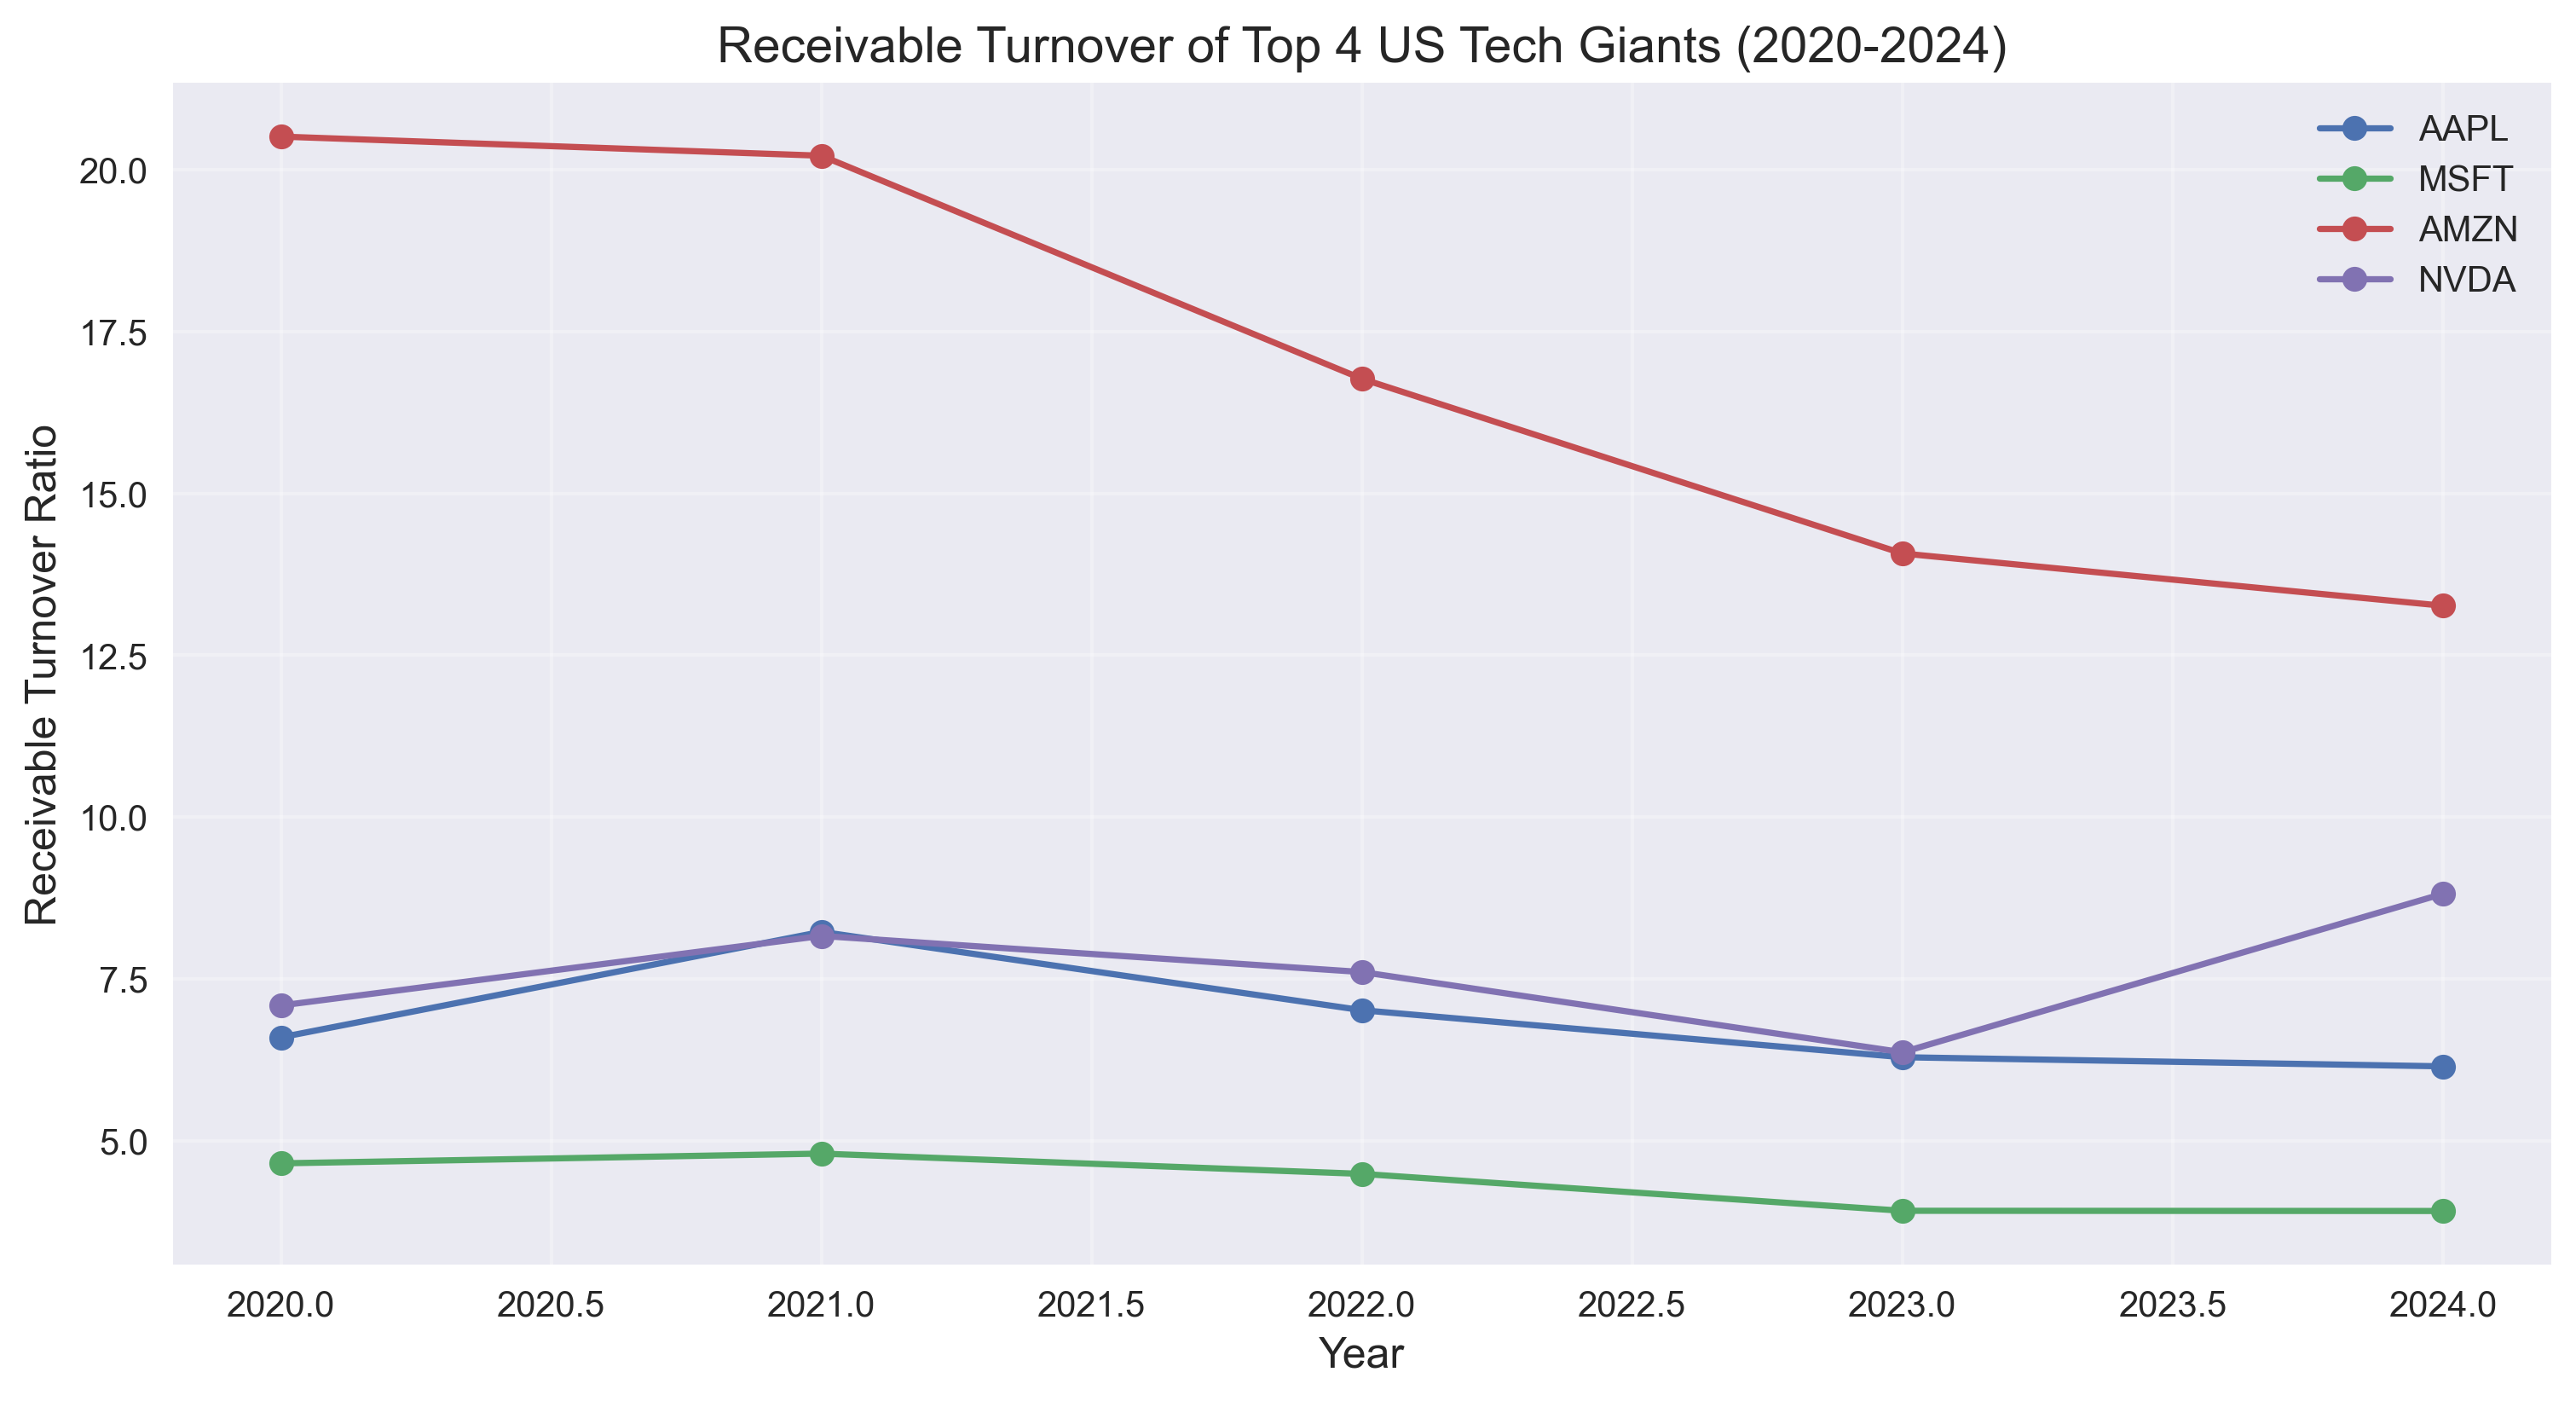

In [17]:
plt.figure(figsize=(12, 6))
for tic in ['AAPL', 'MSFT', 'AMZN', 'NVDA']:
    df = data_final[data_final['tic'] == tic]
    plt.plot(df['year'], df['receivable_turnover'], marker='o', label=tic)
    
plt.title('Receivable Turnover of Top 4 US Tech Giants (2020-2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Receivable Turnover Ratio', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Total Asset Turnover Trend

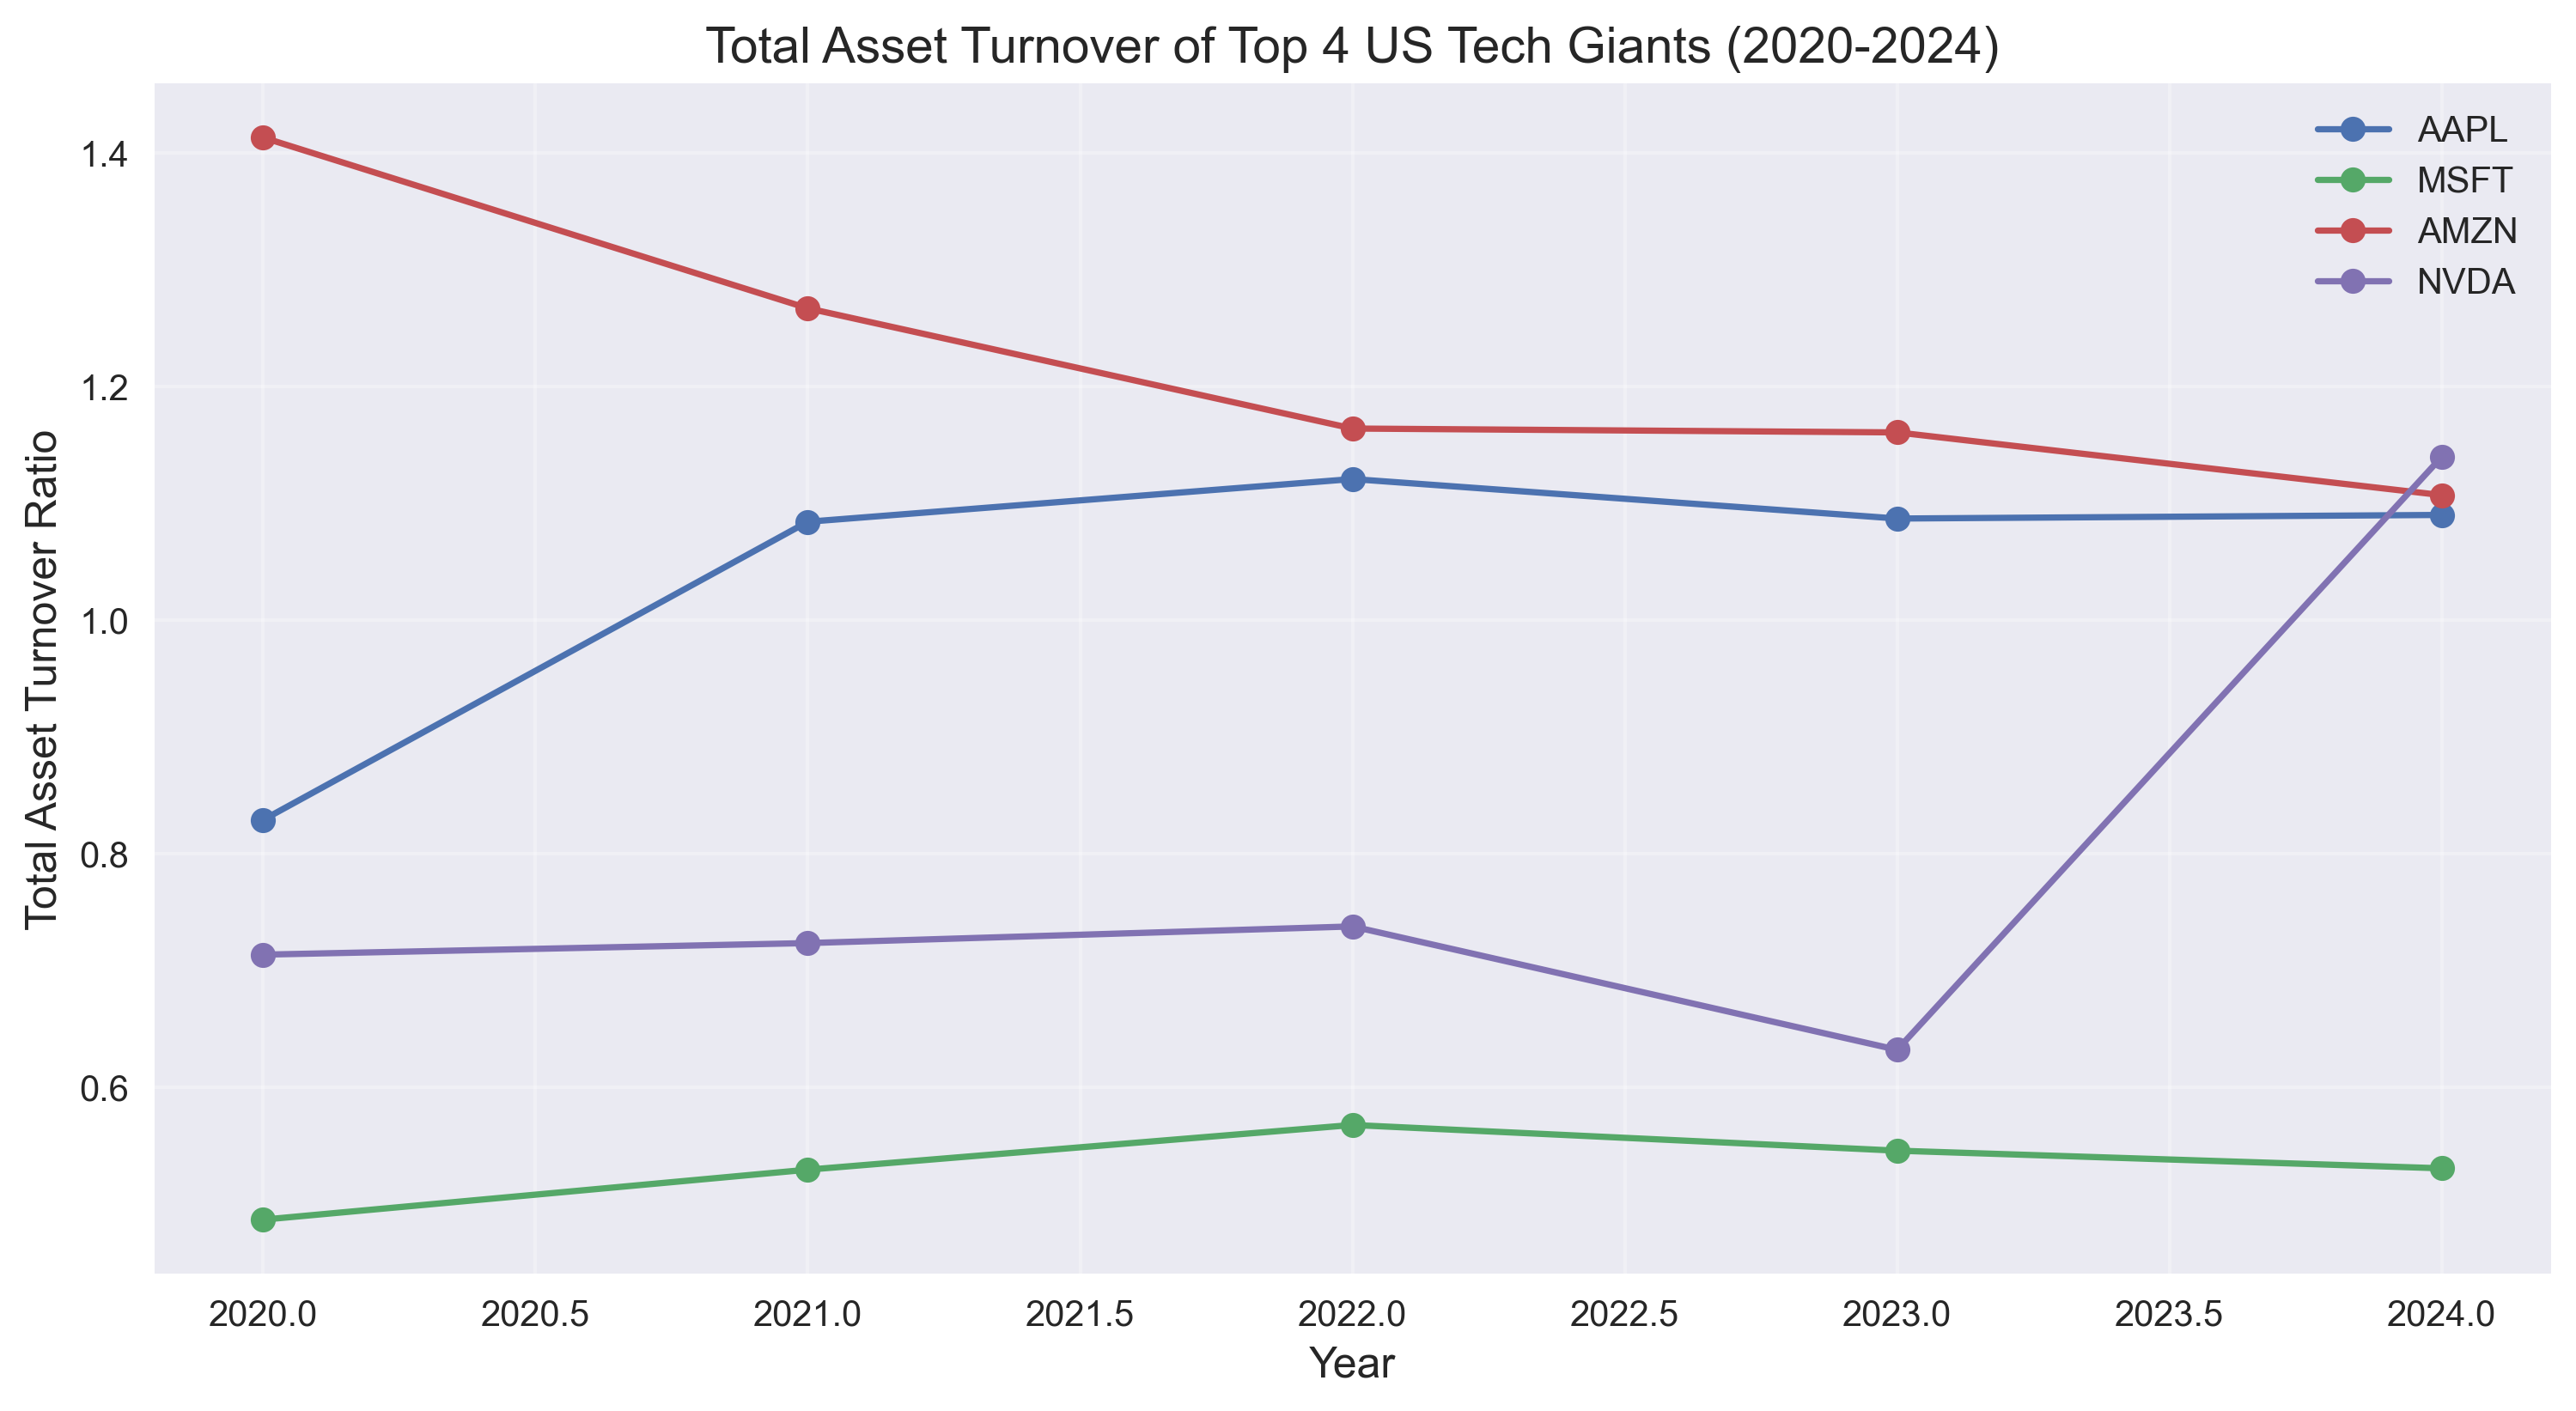

In [18]:
plt.figure(figsize=(12, 6))
for tic in ['AAPL', 'MSFT', 'AMZN', 'NVDA']:
    df = data_final[data_final['tic'] == tic]
    plt.plot(df['year'], df['total_asset_turnover'], marker='o', label=tic)
    
plt.title('Total Asset Turnover of Top 4 US Tech Giants (2020-2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Asset Turnover Ratio', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Key Findings
- **Inventory**: Microsoft improved strongly in 2024; Apple remained stable; Amazon had the lowest ratio.
- **Receivables**: Amazon showed a consistent downward trend; NVIDIA improved slightly.
- **Total Assets**: NVIDIA improved notably in 2024 due to AI chip demand; Amazon declined slightly.
- **Overall**: NVIDIA and Microsoft showed the most efficiency improvements.

## 9. Limitations
- **Industry-Specific Differences**: Operating efficiency ratios vary significantly across industries, so direct comparisons between companies with different business models should be made with caution.
- **Accounting Differences**: Companies may use different accounting methods for inventory valuation and depreciation, which can affect the comparability of ratios.
- **Limited Time Period**: The analysis only covers five years (2020-2024), which includes the post-pandemic period and may not represent long-term trends.
- **Limited Metrics**: This analysis focuses only on three operating efficiency ratios and does not consider profitability, liquidity, or solvency metrics.

In [19]:
db.close()